# CSV_file_Linear_Regression_Keras

### Keras 모델을 이용하여, 입력 1개, 출력 1개인 Linear Regression을 구현하라
### (Colab을 사용하는 경우 "files/LinearRegression.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
pandas Version :2.2.2


> ### Input and Label

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_04_CSV_file_Linear_Regression_Keras/files/LinearRegression.csv'
else :
  files_path = '../files/LinearRegression.csv'

In [4]:
# LinearRegression.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,X,Y
0,1,3.888889
1,2,4.555556
2,3,5.222222
3,4,5.888889
4,5,6.555556


In [5]:
df[['X','Y']]

,X,Y
0,1,3.888889
1,2,4.555556
2,3,5.222222
3,4,5.888889
4,5,6.555556
...,...,...
295,296,200.555556
296,297,201.222222
297,298,201.888889
298,299,1.888889


In [6]:
x_input = tf.constant(df['X'], dtype=tf.float32)
labels = tf.constant(df['Y'], dtype=tf.float32)

print(x_input.shape, labels.shape)

(300,) (300,)


In [7]:
x_input = tf.reshape(x_input, (-1,1))
labels = tf.reshape(labels, (-1,1))

print(x_input.shape, labels.shape)

(300, 1) (300, 1)


In [8]:
# 1. Min Max Scaler 적용
x_input_org = x_input
x_min, x_max = np.min(x_input, axis=0), np.max(x_input, axis=0)
x_input = (x_input-x_min)/(x_max-x_min)

In [9]:
# 2. Keras Model 정의, Model compile, Model summary
model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(1, )),
  tf.keras.layers.Dense(1)
])

model.compile(optimizer='sgd',
              loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Model Fit

In [10]:
%%time
history = model.fit(x_input, labels, epochs=1000)

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12051.0986  
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7905.3784 
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 5643.2456
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4190.8467
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3093.0393
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2732.6279  
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2306.4370 
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1960.1929 
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1931.0470 
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1800.3174 
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1788.9553 
Epoch 12/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1630.9639 
Epoch 13/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1618.6283 
Epoch 14/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1657.2312

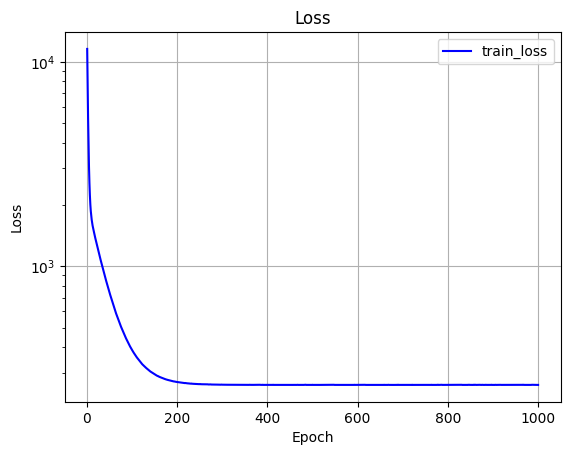

In [11]:
# 4. loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.semilogy()
plt.show()

In [12]:
# 5. parameter(W,B) 출력
w=model.get_weights()
print(w)

[array([[191.04704]], dtype=float32), array([6.6538644], dtype=float32)]


In [13]:
# 6. Test (x_input 사용)
H_x = model.predict(x_input)
for x,h,l in zip(x_input, H_x, labels):
  print("x:{}, h:{}, l:{}".format(x,h,l))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
x:[0.], h:[6.6538644], l:[3.8888888]
x:[0.00334448], h:[7.2928176], l:[4.5555553]
x:[0.00668896], h:[7.9317713], l:[5.2222223]
x:[0.01003344], h:[8.5707245], l:[5.888889]
x:[0.01337793], h:[9.209678], l:[6.5555553]
x:[0.01672241], h:[9.848631], l:[7.2222223]
x:[0.02006689], h:[10.487584], l:[7.888889]
x:[0.02341137], h:[11.126537], l:[8.555555]
x:[0.02675585], h:[11.7654915], l:[9.222222]
x:[0.03010033], h:[12.404444], l:[9.888889]
x:[0.03344481], h:[13.043398], l:[10.555555]
x:[0.0367893], h:[13.682351], l:[11.222222]
x:[0.04013378], h:[14.321304], l:[11.888889]
x:[0.04347826], h:[14.9602585], l:[12.555555]
x:[0.04682274], h:[15.599211], l:[13.222222]
x:[0.05016723], h:[16.238165], l:[13.888889]
x:[0.05351171], h:[16.877117], l:[14.555555]
x:[0.05685619], h:[17.516071], l:[15.222222]
x:[0.06020067], h:[18.155024], l:[15.888889]
x:[0.06354515], h:[18.793978], l:[16.555555]
x:[0.06688963], h:[19.43293], l:[17.222221]
x:[0.07023411], h:[20.071884],

In [14]:
# 7. Predict (X가 115.5일 경우 Y 예측)
def predict(x):
  return model.predict((x-x_min)/(x_max-x_min))

X = tf.constant([[115.5]], dtype= tf.float32)
print("X: {} -> Y: {:>7.4}".format(X[0,0], predict(X)[0,0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
X: 115.5 -> Y:   79.81


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


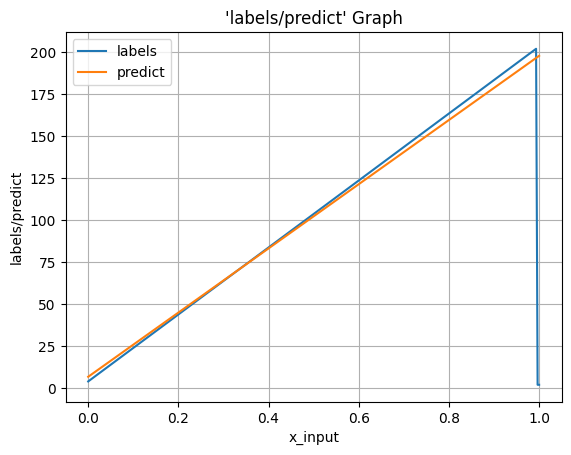

In [15]:
# 8. labels(정답)과 predict(예측값)를 비교할 수 있는 그래프 출력
H_x = model.predict(x_input)

plt.title("'labels/predict' Graph")
plt.xlabel("x_input")
plt.ylabel("labels/predict")
plt.plot(x_input.numpy().reshape((-1,)), labels.numpy().reshape((-1,)), label='labels')
plt.plot(x_input.numpy().reshape((-1,)), H_x.reshape((-1,)), label='predict')
plt.grid(True)
plt.legend(loc='best')
plt.show()